# Compounding Analysis
The EDA notebook ended with a question: On an average, how many minutes does a train gain or lose **per stop** as it travels its route
and which lines systematically **recover** versus systematically **spiral**?

Two things to keep in mind:
1. A train that spirals badly enough gets **cancelled mid-route**, so its latest stops are
**absent** from the data. A naive "average delay by station position" curve is therefore
useless.

3. Deutsch Bahn gives considerable amount of time slack in its timetables, so late-route stops often **recover** time. This
notebook does **not** assume delay grows. It measures the per-stop change in whichever direction it
actually runs, and reports recovery if that's what the data shows.

4. Delay convention: `delay_in_min` is the **arrival** delay at a stop. The origin
stop of a ride has no arrival, so its delay is null/zero and is handled explicitly.

# 0. Setup

In [1]:
import duckdb
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("/Users/swarnavabanerjee/Documents/Old Files/ML Projects/db-analysis/data/monthly_processed_data")
DATA_GLOB = str(DATA_DIR / "*.parquet")
MAJOR_TYPES = ("ICE", "IC", "EC", "RE", "RB", "S")

con = duckdb.connect() 

data_end = con.execute(f"SELECT max(time)::date FROM read_parquet('{DATA_GLOB}')").fetchone()[0]
ANALYSIS_START, ANALYSIS_END = "2025-11-02", str(data_end)
print("Window:", ANALYSIS_START, "->", ANALYSIS_END)

Window: 2025-11-02 -> 2026-07-31


### 0.1 Verify the journey key

In [2]:
ids = con.execute(f"""
    SELECT
        count(*)                                                           AS rows,
        count(DISTINCT train_line_ride_id)                                 AS distinct_ids,
        count(DISTINCT train_line_ride_id || '_' || (time::date)::VARCHAR) AS id_date_pairs
    FROM read_parquet('{DATA_GLOB}')
    WHERE time >= '{ANALYSIS_START}' AND time < '{ANALYSIS_END}'
""").df()
print(ids.to_string(index=False))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

     rows  distinct_ids  id_date_pairs
130564016        253373       11133583


## 1. Per-stop change in delay within a ride

For each ride, order its stops by `train_line_station_num` and take the change in arrival delay
from one stop to the next: `delta = delay[n] - delay[n-1]`.

Why the delta and not the raw delay-by-position?

Averaging deltas across **all** consecutive stop
pairs gives the unconditional expected change per stop. It does not condition on a train already
being late, so it ignores the regression-to-the-mean artefact that gives the reason "late trains get
later" phrasings. A positive mean delta = delay accumulates per stop; negative = it recovers.

In [3]:
deltas = con.execute(f"""
    WITH stops AS (
        SELECT
            train_line_ride_id AS rid,
            (time::date)        AS ride_date,
            train_line_station_num AS pos,
            train_type,
            delay_in_min AS delay
        FROM read_parquet('{DATA_GLOB}')
        WHERE NOT is_canceled AND delay_in_min IS NOT NULL
          AND time >= '{ANALYSIS_START}' AND time < '{ANALYSIS_END}'
    ),
    stepped AS (
        SELECT
            train_type,
            delay - lag(delay) OVER (
                PARTITION BY rid, ride_date ORDER BY pos
            ) AS delta
        FROM stops
    )
    SELECT
        train_type,
        count(*)                AS stop_pairs,
        round(avg(delta), 3)    AS mean_delta_per_stop,
        round(stddev(delta), 2) AS sd_delta
    FROM stepped
    WHERE delta IS NOT NULL AND train_type IN {MAJOR_TYPES}
    GROUP BY train_type
    ORDER BY mean_delta_per_stop DESC
""").df()
deltas

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,train_type,stop_pairs,mean_delta_per_stop,sd_delta
0,ICE,1290637,1.450,11.20
1,IC,414247,1.073,7.95
2,EC,26034,0.817,14.58
3,RE,11166033,0.315,4.17
4,RB,15203754,0.149,2.60
5,S,52525160,0.089,1.92


- If `mean_delta_per_stop > 0`, it means that the train service  accumulates delay as
it travels.
- If `mean_delta_per_stop< 0`,  it recovers on average (due to slack time).


## 2. Survivorship bias from mid-route cancellation

Share of journeys that were running and then had cancelled stops later in the route, the **spirals**
whose worst stops are missing from Section 1.

In [4]:
truncation = con.execute(f"""
    WITH ride_stops AS (
        SELECT
            train_line_ride_id AS rid,
            (time::date)        AS ride_date,
            train_type,
            train_line_station_num AS pos,
            is_canceled
        FROM read_parquet('{DATA_GLOB}')
        WHERE train_type IN {MAJOR_TYPES}
          AND time >= '{ANALYSIS_START}' AND time < '{ANALYSIS_END}'
    ),
    per_ride AS (
        SELECT
            train_type, rid, ride_date,
            max(pos)                                AS last_pos,
            max(pos) FILTER (WHERE NOT is_canceled) AS last_run_pos,
            count(*) FILTER (WHERE is_canceled)     AS cancelled_stops
        FROM ride_stops
        GROUP BY train_type, rid, ride_date
    )
    SELECT
        train_type,
        count(*) AS journeys,
        round(100.0 * avg((cancelled_stops > 0
             AND last_run_pos IS NOT NULL
             AND last_pos > last_run_pos)::int), 2) AS pct_truncated_midroute
    FROM per_ride
    GROUP BY train_type
    ORDER BY pct_truncated_midroute DESC
""").df()
truncation

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,train_type,journeys,pct_truncated_midroute
0,ICE,157138,4.23
1,S,3256801,3.71
2,IC,51847,3.07
3,RE,1184931,2.35
4,RB,1802057,1.31
5,EC,14947,0.92


`pct_truncated_midroute` is the share of rides that were running and then
had cancelled stops later in the route. They are the trajectories whose bad tail is missing.

## 3. Delay trajectory within journey

Absolute `station_num` mixes trains of different route lengths (e.g. stop 10 is mid-route for one train,
the terminus for another). Normalise each stop to its fraction of the route (0 = origin, 1 = final),
bucket into deciles, and plot mean delay across the journey. This shows the *shape*: does delay ramp
up and stay, or ramp up then recover near the end?

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

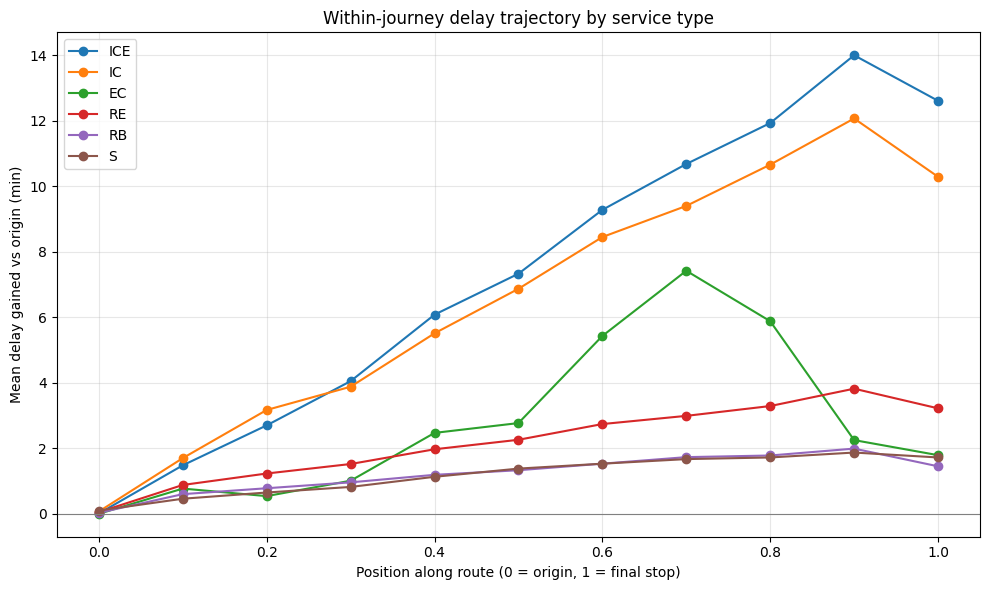

,train_type,route_frac,mean_gain_vs_origin,stops
0,EC,0.0,0.00,3990
1,EC,0.1,0.77,175
2,EC,0.2,0.54,933
3,EC,0.3,1.01,1753
4,EC,0.4,2.47,1510
...,...,...,...,...
61,S,0.6,1.53,5350947
62,S,0.7,1.67,4913059
63,S,0.8,1.72,5684626
64,S,0.9,1.87,5342215


In [5]:
traj = con.execute(f"""
    WITH stops AS (
        SELECT
            train_type,
            delay_in_min AS delay,
            train_line_station_num AS pos,
            first_value(delay_in_min) OVER (
                PARTITION BY train_line_ride_id, (time::date)
                ORDER BY train_line_station_num
            ) AS origin_delay,
            max(train_line_station_num) OVER (
                PARTITION BY train_line_ride_id, (time::date)
            ) AS max_pos
        FROM read_parquet('{DATA_GLOB}')
        WHERE NOT is_canceled AND delay_in_min IS NOT NULL
          AND train_type IN {MAJOR_TYPES}
          AND time >= '{ANALYSIS_START}' AND time < '{ANALYSIS_END}'
    )
    SELECT
        train_type,
        round(10.0*(pos-1)/(max_pos-1))/10.0 AS route_frac,
        round(avg(delay - origin_delay), 2)  AS mean_gain_vs_origin,
        count(*)                              AS stops
    FROM stops
    WHERE max_pos > 1
    GROUP BY train_type, route_frac
    ORDER BY train_type, route_frac
""").df()

plt.figure(figsize=(10, 6))
for t in [x for x in ("ICE","IC","EC","RE","RB","S") if x in set(traj["train_type"])]:
    d = traj[traj["train_type"] == t]
    plt.plot(d["route_frac"], d["mean_gain_vs_origin"], marker="o", label=t)
plt.axhline(0, color="grey", lw=0.8)
plt.xlabel("Position along route (0 = origin, 1 = final stop)")
plt.ylabel("Mean delay gained vs origin (min)")
plt.title("Within-journey delay trajectory by service type")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
traj

- A line hugging 0, means that trains hold their starting delay (no compounding). 
- A line rising to
a positive value at frac 1.0, means that service accumulates that many minutes across its route.

## 4. Which station's trains gain / shed delay at

Per-stop delay change (`delay - lag(delay)` within a journey) attributed to the station arrived into.
Ranked over stations with enough arrivals to be stable. Frame as *delay observed arriving into X*,
not *X causes delay* — a station inherits where it sits on routes.

In [6]:
station_effect = con.execute(f"""
    WITH stops AS (
        SELECT
            train_line_ride_id AS rid,
            (time::date)        AS ride_date,
            station_name,
            train_line_station_num AS pos,
            delay_in_min AS delay
        FROM read_parquet('{DATA_GLOB}')
        WHERE NOT is_canceled AND delay_in_min IS NOT NULL
          AND train_type IN {MAJOR_TYPES}
          AND time >= '{ANALYSIS_START}' AND time < '{ANALYSIS_END}'
    ),
    stepped AS (
        SELECT
            station_name,
            delay - lag(delay) OVER (
                PARTITION BY rid, ride_date ORDER BY pos
            ) AS delta_here
        FROM stops
    )
    SELECT
        station_name,
        count(*)                    AS arrivals,
        round(avg(delta_here), 2)   AS mean_delta_at_station
    FROM stepped
    WHERE delta_here IS NOT NULL
    GROUP BY station_name
    HAVING count(*) >= 500
    ORDER BY mean_delta_at_station DESC
""").df()

print("Worst stations (trains arrive more delayed than they left the prior stop):")
display(station_effect.head(12))
print()
print("Best stations (trains recover time coming in):")
display(station_effect.tail(12).iloc[::-1])

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Worst stations (trains arrive more delayed than they left the prior stop):


,station_name,arrivals,mean_delta_at_station
0,Oberdachstetten,953,3.67
1,Kirchhundem,756,3.56
2,Wolfsburg Hbf,18056,3.25
3,Albstadt-Ebingen,5009,3.16
4,Grimmen,8307,2.45
5,Bremerhaven Hbf,6988,2.32
6,Bad Holzhausen,1274,2.25
7,Wörth (Isar),7549,2.21
8,Hannover Hbf,66898,2.14
9,Wangen (Allgäu),1961,2.02



Best stations (trains recover time coming in):


,station_name,arrivals,mean_delta_at_station
4220,Rakow,8334,-2.11
4219,Elze (Han),8236,-1.95
4218,Neustadt (Holst),6933,-1.75
4217,Ostseebad Binz,1654,-1.69
4216,Oberstdorf,6254,-1.61
4215,Köln-Worringen,31103,-1.50
4214,Gerwisch,4309,-1.45
4213,Nauen,1474,-1.39
4212,Teterow,8110,-1.32
4211,Oldenburg (Oldb) Hbf,13043,-1.31


In [7]:
dist = con.execute(f"""
    WITH stops AS (
        SELECT train_line_ride_id AS rid, (time::date) AS ride_date,
               train_line_station_num AS pos, train_type, delay_in_min AS delay
        FROM read_parquet('{DATA_GLOB}')
        WHERE NOT is_canceled AND delay_in_min IS NOT NULL
          AND time >= '{ANALYSIS_START}' AND time < '{ANALYSIS_END}'
    ),
    stepped AS (
        SELECT train_type,
               delay - lag(delay) OVER (PARTITION BY rid, ride_date ORDER BY pos) AS delta
        FROM stops
    )
    SELECT train_type,
           round(avg(delta),3)                 AS mean_delta,
           median(delta)                       AS median_delta,
           round(100.0*avg((delta>0)::int),1)  AS pct_gain,
           round(100.0*avg((delta=0)::int),1)  AS pct_flat,
           round(100.0*avg((delta<0)::int),1)  AS pct_recover,
           round(quantile_cont(delta,0.95),1)  AS p95,
           round(quantile_cont(delta,0.99),1)  AS p99
    FROM stepped
    WHERE delta IS NOT NULL AND train_type IN {MAJOR_TYPES}
    GROUP BY train_type ORDER BY mean_delta DESC
""").df()
dist

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,train_type,mean_delta,median_delta,pct_gain,pct_flat,pct_recover,p95,p99
0,ICE,1.448,0.0,42.2,20.8,37.1,12.0,38.0
1,IC,1.074,0.0,39.8,28.2,32.0,8.0,26.0
2,EC,0.785,0.0,38.0,20.6,41.4,11.0,48.0
3,RE,0.315,0.0,28.9,46.7,24.4,3.0,9.0
4,RB,0.149,0.0,23.8,55.1,21.1,2.0,6.0
5,S,0.089,0.0,21.3,60.1,18.6,1.0,3.0


## 5. Conclusion

**Delay does not increase uniformly. The median change in delay per-stop is 0 for every service type. Net compounding is real but tail-driven, and concentrated in long-distance services.**

- ** For Long-distance (ICE, IC, EC): net ~0.8–1.4 min/stop, driven by a heavy right tail.** For ICE, 42% of stops lose time and 37% recover it. A near-balanced churn that only tilts positive because loss events dwarf recoveries: the worst 1% of stops add 38+ min (IC 26, EC 49). Over a full route this compounds to roughly 10 min for the average ICE. The story is not "every stop loses 1.4 min". It's "most stops are a wash, and a minority of high-impact stops drive the accumulation."
- **For Regional (RE, RB, S) trains mostly hold their starting delay.** S-Bahn is flat at 60% of stops with a p99 of just 3 min; net per-stop change ~0.09 min. Compounding is essentially a long-distance phenomenon.
- **Survivorship makes these lower bounds.** ICE has both the fastest accumulation and the highest mid-route cancellation (4.23% of journeys truncate). The worst spirals are cancelled and drop out, so true long-distance compounding is at least what's shown.
- **Where it happens (with a caveat).** Largest per-stop losses cluster at Bornheim-Sechtem (+1.57) and adjacent Roisdorf (+1.43), Poggenhagen (+1.12); largest recoveries at Herrlingen (−1.09) and the Hanau/Maintal corridor. Adjacent stations sharing an effect signals this is partly *route position*. A station inherits accumulated delay from where it sits on journeys, not a station-intrinsic cause. It is read as "delay observed arriving into X," not "X causes delay."

**Bottom line:** DB long-distance delay is shock-driven and heavy-tailed. A minority of bad stops, not steady creep. While regional services largely preserve whatever delay they start with.

**Method note:** `train_line_ride_id` is reused across dates; all per-journey measures are keyed on `(train_line_ride_id, date)`. Journeys crossing midnight are split by the date boundary.